In [33]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, make_smoothing_spline
from scipy.integrate import cumulative_trapezoid
import torch
import torch.nn.functional as _F

from plot_style import set_style, C, vline
from utils import bs_call_price, mc_iv, bs_implied_vol
from heston import Heston
from pde_solver import solve_brownian_transport_pde

set_style()
np.set_printoptions(precision=6, suppress=True)

### Brownian Motion reference model (inline)

The `BrownianMotion` class 

In [34]:
class BrownianMotion:
    
    def __init__(self, s0, sigma):
        self.s0    = float(s0)
        self.sigma = float(sigma)

    def kernel(self, dt, strikes, lam=None):
        dx  = strikes[1] - strikes[0]
        raw = st.norm.pdf(strikes[1:-1], loc=self.s0, scale=self.sigma * np.sqrt(dt))
        return raw * dx

    def cdf(self, t, strikes):
        vals = st.norm.cdf(strikes[1:], loc=self.s0, scale=self.sigma * np.sqrt(t))
        return interp1d(strikes[1:], vals, kind='linear',bounds_error=False, fill_value=(0.0, 1.0))

    def quantile(self, t, strikes):
        vals = st.norm.cdf(strikes[1:], loc=self.s0, scale=self.sigma * np.sqrt(t))
        return interp1d(vals, strikes[1:], kind='linear', bounds_error=False, fill_value=(strikes[1], strikes[-1]))

    def simulate_terminal(self, T, n_paths, seed=None):
        rng = np.random.default_rng(seed)
        return self.s0 + self.sigma * np.sqrt(T) * np.random.normal(n_paths)

### Bass building blocks (inline)

`convolve`, `fixed_point`, `pathwise_second_moment_deriv`, `second_moment_curve`.

In [35]:
def convolve(f, kernel, fill_left, fill_right, mode):
    """
    Apply a (possibly asymmetric) kernel to f using PyTorch conv1d.

    mode='forward'  : true convolution  integral f(x-z)*k(z) dz  (pushes CDF forward)
    mode='backward' : cross-correlation integral f(x+z)*k(z) dz  (conditional expectation)
    """
    f_t = torch.as_tensor(np.asarray(f, dtype=np.float64), dtype=torch.float64)
    k_t = torch.as_tensor(np.asarray(kernel, dtype=np.float64), dtype=torch.float64)
    N     = k_t.numel()
    pad_l = N // 2
    pad_r = N - 1 - pad_l
    x = f_t.view(1, 1, -1)
    if mode == 'forward':
        k_t = torch.flip(k_t, dims=[0])
    elif mode != 'backward':
        raise ValueError("mode must be 'forward' or 'backward'")
    k_t   = k_t.view(1, 1, -1)
    x_pad = _F.pad(
        _F.pad(x, (pad_l, 0), mode='constant', value=fill_left),
        (0, pad_r), mode='constant', value=fill_right,
    )
    return _F.conv1d(x_pad, k_t).view(-1).numpy()


def fixed_point(operator, F0, tol=1e-5, max_iter=60, verbose=True):
    """Iterate F <- operator(F) until ||Delta F||_inf < tol."""
    F, errors = F0.copy(), []
    for i in range(max_iter):
        F1  = operator(F)
        err = float(np.max(np.abs(F1 - F)))
        errors.append(err)
        F   = F1
        if err < tol:
            if verbose:
                print(f"  Converged in {i+1} iterations, ||Delta F||_inf = {err:.2e}")
            break
        if verbose and (i + 1) % 10 == 0:
            print(f"  iter {i+1:3d}  ||Delta F||_inf = {err:.2e}")
    else:
        if verbose:
            print(f"  Warning: did not converge in {max_iter} iterations")
    return F, errors


# ---- BM path simulation ----

def simulate_bm(y0, sigma, T, n_paths, n_steps, seed=None):
    """
    Simulate arithmetic BM paths: dY = sigma * dW.

    Returns
    -------
    Y  : (n_paths, n_steps+1)  price paths
    dW : (n_paths, n_steps)    Brownian increments  (sqrt(dt)-scaled)
    """
    rng   = np.random.default_rng(seed)
    dt    = T / n_steps
    dW    = rng.standard_normal((n_paths, n_steps)) * np.sqrt(dt)
    Y     = np.zeros((n_paths, n_steps + 1))
    Y[:, 0] = y0
    for i in range(n_steps):
        Y[:, i+1] = Y[:, i] + sigma * dW[:, i]
    return Y, dW


def apply_bm_ito_transport(Y_paths, dW, pde_data, sigma):
    """
    Apply the Itô transport formula to BM paths.

        dX = sigma * f_x(t, Y_t) * dW_t

    Parameters
    ----------
    Y_paths : (n_paths, n_steps+1)  BM reference paths from simulate_bm
    dW      : (n_paths, n_steps)    Brownian increments from simulate_bm
    pde_data: dict from solve_brownian_transport_pde
    sigma   : BM vol (same as used in simulate_bm)

    Returns
    -------
    X : (n_paths, n_steps+1)  Bass LV price paths
    """
    x_grid  = pde_data['x_grid']
    f_time  = pde_data['f_time']
    fx_time = pde_data['fx_time']
    n_paths, n_times = Y_paths.shape
    X = np.zeros_like(Y_paths)
    X[:, 0] = np.interp(Y_paths[:, 0], x_grid, f_time[0])
    for k in range(n_times - 1):
        fx       = np.interp(Y_paths[:, k], x_grid, fx_time[k])
        X[:, k+1] = X[:, k] + sigma * fx * dW[:, k]
    return X


def bm_pathwise_second_moment_deriv(Y_paths, pde_data, sigma):
    """
    Pathwise (IPA) estimator of m'(t) = d/dt E[X_t^2] for BM reference.

        m'(t) = sigma^2 * E[f_x(t, Y_t)^2]
    """
    x_grid  = pde_data['x_grid']
    fx_time = pde_data['fx_time']
    n_times = Y_paths.shape[1]
    mp = np.zeros(n_times)
    for k in range(n_times):
        fx    = np.interp(Y_paths[:, k], x_grid, fx_time[k])
        mp[k] = (sigma**2 * fx**2).mean()
    return mp


def second_moment_curve(mp_list, t_list, x0):
    """Assemble m(t) and m'(t) from per-interval pathwise estimates."""
    mp_full = np.concatenate([mp_list[0]] + [mp[1:] for mp in mp_list[1:]])
    t_full  = np.concatenate([t_list[0]]  + [t[1:]  for t  in t_list[1:]])
    m_full  = x0**2 + cumulative_trapezoid(mp_full, t_full, initial=0)
    return t_full, m_full, mp_full

In [36]:
s0 = 100.0
T  = np.array([0.0, 0.25, 1.0])   # calibration maturities
tau1  = T[1] - T[0]               # length of first interval
delta = T[2] - T[1]               # length of second interval

# Single Heston for the main experiment (Sections 1–4)
heston = Heston(s0=s0, v0=0.05, kappa=1.0, theta=0.2, xi=1.0, rho=-0.7)

# Four Heston parametrisations designed to produce distinct ATM vol shapes.
# ATM vol ≈ sqrt( theta + (v0-theta)*(1-exp(-kappa*T))/(kappa*T) )
#
#  Case 1 — Backwardation  : v0 >> theta, high kappa  → strong decrease  50%→20%
#  Case 2 — Flat           : v0  = theta              → nearly constant  ~30%
#  Case 3 — Slow contango  : v0 << theta, low  kappa  → slow steady rise 14%→22%
#  Case 4 — Fast then flat : v0 << theta, high kappa  → steep then plateau 10%→39%
heston_params = [
    {'s0': s0, 'v0': 0.25, 'kappa': 3.0, 'theta': 0.04, 'xi': 0.4, 'rho': -0.6},
    {'s0': s0, 'v0': 0.09, 'kappa': 2.0, 'theta': 0.09, 'xi': 0.3, 'rho': -0.5},
    {'s0': s0, 'v0': 0.02, 'kappa': 0.4, 'theta': 0.16, 'xi': 0.3, 'rho': -0.5},
    {'s0': s0, 'v0': 0.01, 'kappa': 4.0, 'theta': 0.20, 'xi': 0.5, 'rho': -0.6},
]
heston_list = [Heston(**d) for d in heston_params]

# Reference model: Brownian Motion
# sigma chosen so BM std at T2=1 ≈ Heston normal vol × s0  (≈10% BS vol × s0)
sigma_bm = 10.0
bm = BrownianMotion(s0=s0, sigma=sigma_bm)

# Grid half-widths (6σ covers 99.99997% of Gaussian mass)
bm_std_t1 = bm.sigma * np.sqrt(tau1)    # ≈  5.00
bm_std_dt = bm.sigma * np.sqrt(delta)   # ≈  8.66

### 1. Market model: Heston

We use a Heston stochastic-volatility model as the proxy for the market.
Its risk-neutral marginals $\mu_1 = \mathcal{L}(S_{T_1})$ and $\mu_2 = \mathcal{L}(S_{T_2})$
are the calibration targets.  CDF and quantile function are precomputed by numerical quadrature.

In [37]:
print("Precomputing Heston CDF / QF at T₁ and T₂  (≈ 1–2 min)…")

from dataclasses import dataclass

@dataclass
class Market:
    model : None 
    cdf : None 
    qf : None

markets = []

for i in range(len(heston_list)):
    hest = heston_list[i]

    cdf_mu = [None] + [hest.cdf_interpolate(t, n=300) for t in T[1:]]
    qf_mu  = [None] + [hest.quantile_interpolate(t, n=300) for t in T[1:]]

    print(f'heston params : {heston_params[i]}')
    print(f"  μ₁ support (1%–99%): [{qf_mu[1](0.01):.2f}, {qf_mu[1](0.99):.2f}]")
    print(f"  μ₂ support (1%–99%): [{qf_mu[2](0.01):.2f}, {qf_mu[2](0.99):.2f}] \n")
    m = Market(model = hest, cdf = cdf_mu, qf = qf_mu)
    markets.append(m)

Precomputing Heston CDF / QF at T₁ and T₂  (≈ 1–2 min)…
heston params : {'s0': 100.0, 'v0': 0.25, 'kappa': 3.0, 'theta': 0.04, 'xi': 0.4, 'rho': -0.6}
  μ₁ support (1%–99%): [55.18, 154.12]
  μ₂ support (1%–99%): [37.06, 182.76] 

heston params : {'s0': 100.0, 'v0': 0.09, 'kappa': 2.0, 'theta': 0.09, 'xi': 0.3, 'rho': -0.5}
  μ₁ support (1%–99%): [66.88, 136.20]
  μ₂ support (1%–99%): [41.94, 179.37] 

heston params : {'s0': 100.0, 'v0': 0.02, 'kappa': 0.4, 'theta': 0.16, 'xi': 0.3, 'rho': -0.5}
  μ₁ support (1%–99%): [78.85, 117.74]
  μ₂ support (1%–99%): [50.72, 149.41] 

heston params : {'s0': 100.0, 'v0': 0.01, 'kappa': 4.0, 'theta': 0.2, 'xi': 0.5, 'rho': -0.6}
  μ₁ support (1%–99%): [67.35, 132.26]
  μ₂ support (1%–99%): [31.88, 211.14] 



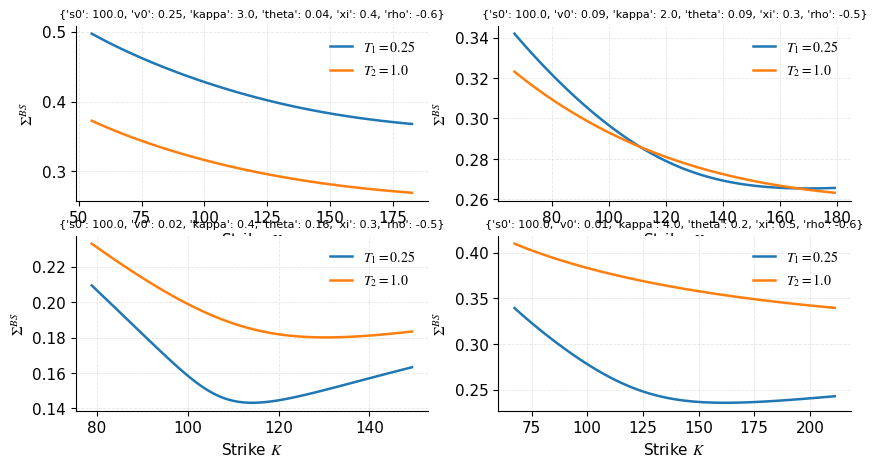

In [38]:
fig, ax = plt.subplots(2, 2, figsize = (10,5))
ax = ax.flatten()

for i in range(len(markets)):

    mkt = markets[i]
    hest = mkt.model
    K_plot = np.linspace(mkt.qf[1](0.01), mkt.qf[2](0.99), 80)

    for j, lbl in [(1, f"$T_1 = {T[1]}$"), (2, f"$T_2 = {T[2]}$")]:
        ax[i].plot(K_plot, hest.implied_vol(T[j], K_plot), label=lbl)

    ax[i].set_title(f"{heston_params[i]}", fontsize=8)
    ax[i].set_xlabel("Strike $K$");  ax[i].set_ylabel("$\\Sigma^{BS}$")
    ax[i].legend()

### 2. Bass BM calibration — $\phi_1$, $\phi_2$, $\psi_1$ for each market

For each Heston model in `markets` we build:

* **$\phi_1$** — Brenier map at $T_1$: pushes the BM law forward to match $\mu_1$
* **$\mathcal{A}$-operator fixed point** — finds the conditional distribution $F_\alpha$ that makes the two-date joint calibration consistent
* **$\phi_2$, $\psi_1$** — second transport map and its glueing complement

In [ ]:
n_paths   = 200_000
n_steps_1 = 63     # ≈ 252 × tau1
n_steps_2 = 189    # ≈ 252 × delta
W1, W2    = 7, 9   # BM-sigma multiples for the T1- and delta-interval grids

calibrations = []

for idx, mkt in enumerate(markets):
    qf_mu  = mkt.qf
    cdf_mu = mkt.cdf

    #Strike grids centred at s0
    strikes_t1 = np.linspace(s0 - W1*bm_std_t1, s0 + W1*bm_std_t1, 2*10_000 + 3)
    strikes_dt = np.linspace(s0 - W2*bm_std_dt, s0 + W2*bm_std_dt, 2*10_000 + 3)
    X_dt       = strikes_dt[1:-1] - s0

    kernel_t1 = bm.kernel(tau1,  strikes_t1)
    kernel_dt = bm.kernel(delta, strikes_dt)

    #create brenier maps
    bm_cdf_t1 = bm.cdf(tau1, strikes_t1)
    phi1_vals  = qf_mu[1](np.clip(bm_cdf_t1(strikes_t1[1:]), 1e-8, 1-1e-8))
    phi1       = interp1d(strikes_t1[1:], phi1_vals, kind='linear', bounds_error=False,
                          fill_value=(phi1_vals[0], phi1_vals[-1]))

    # A-operator fixed point
    fill_lo = float(qf_mu[2](1e-8))
    fill_hi = float(qf_mu[2](1 - 1e-8))

    def _make_A_op(kdt, qf2, cdf1, flo, fhi):
        def _A(F):
            G = convolve(F, kdt, 0.0, 1.0, mode='forward')
            H = qf2(np.clip(G, 1e-8, 1-1e-8))
            R = convolve(H, kdt, flo, fhi, mode='backward')
            return cdf1(R)
        return _A

    A_op       = _make_A_op(kernel_dt, qf_mu[2], cdf_mu[1], fill_lo, fill_hi)
    F0         = st.norm.cdf(X_dt, scale=np.sqrt(0.5*(T[1]+T[2])))
    F_alpha, _ = fixed_point(A_op, F0, tol=1e-5, max_iter=60, verbose=False)

    phi2_vals  = qf_mu[2](np.clip(
        convolve(F_alpha, kernel_dt, 0.0, 1.0, mode='forward'), 1e-8, 1-1e-8))
    phi2       = interp1d(X_dt + s0, phi2_vals, kind='linear', bounds_error=False,
                          fill_value=(phi2_vals[0], phi2_vals[-1]))
    Q_alpha    = interp1d(F_alpha, X_dt + s0, kind='linear', bounds_error=False,
                          fill_value=(X_dt[0]+s0, X_dt[-1]+s0))
    psi1_vals  = convolve(phi2_vals, kernel_dt,
                          fill_left=phi2_vals[0], fill_right=phi2_vals[-1], mode='backward')
    psi1       = interp1d(X_dt + s0, psi1_vals, kind='linear', bounds_error=False,
                          fill_value=(psi1_vals[0], psi1_vals[-1]))
    psi1_inv   = interp1d(psi1_vals, X_dt + s0, kind='linear', bounds_error=False,
                          fill_value=(X_dt[0]+s0, X_dt[-1]+s0))

    calibrations.append(dict(
        phi1=phi1, phi2=phi2, psi1=psi1, psi1_inv=psi1_inv, Q_alpha=Q_alpha,
        phi2_vals=phi2_vals, psi1_vals=psi1_vals, X_dt=X_dt,
    ))
    print(f"  market {idx+1}  done")

print("Calibration complete.")

  market 1  done
  market 2  done
  market 3  done
  market 4  done
Calibration complete.


### 3. Itô simulation — heat PDE + BM paths + transport for each market

For each market we:
1. Solve the 1-D backward heat equation on $[0,T_1]$ and $[T_1,T_2]$ with terminal conditions $\phi_1$ and $\phi_2$
2. Simulate BM reference paths and apply the Itô formula $dX_t = \sigma f_x(t,Y_t)\,dW_t$
3. Glue the two intervals via $\xi = \psi_1^{-1}(X_{T_1})$

In [46]:
simulations = []

for idx, (mkt, cal) in enumerate(zip(markets, calibrations)):
    print(f"market {idx+1} / {len(markets)}")

    # ── PDEs ──────────────────────────────────────────────────────────────────
    sol1 = solve_brownian_transport_pde(
        cal['phi1'], x0=s0, sigma0=bm.sigma, T=tau1,
        Nx=601, Nt=n_steps_1, x_width=W1, verbose=False)
    sol2 = solve_brownian_transport_pde(
        cal['phi2'], x0=s0, sigma0=bm.sigma, T=delta,
        Nx=901, Nt=n_steps_2, x_width=W2, verbose=False)

    # ── Interval [0, T₁] ──────────────────────────────────────────────────────
    Y1, dW1 = simulate_bm(s0, bm.sigma, tau1, n_paths, n_steps_1, seed=10)
    X1      = apply_bm_ito_transport(Y1, dW1, sol1, bm.sigma)

    # ── Interval [T₁, T₂]  (shift BM start to ξ = ψ₁⁻¹(X_{T₁})) ────────────
    xi_start = cal['psi1_inv'](X1[:, -1])
    Y2_base, dW2 = simulate_bm(s0, bm.sigma, delta, n_paths, n_steps_2, seed=20)
    Y2 = Y2_base + (xi_start - s0)[:, np.newaxis]
    X2 = apply_bm_ito_transport(Y2, dW2, sol2, bm.sigma)

    # ── Full path grids ────────────────────────────────────────────────────────
    t_grid_1 = np.linspace(0.0, T[1], n_steps_1 + 1)
    t_grid_2 = np.linspace(T[1], T[2], n_steps_2 + 1)
    t_full   = np.concatenate([t_grid_1, t_grid_2[1:]])
    X_full   = np.concatenate([X1, X2[:, 1:]], axis=1)

    simulations.append(dict(
        Y1=Y1, dW1=dW1, X1=X1, sol1=sol1,
        Y2=Y2, dW2=dW2, X2=X2, sol2=sol2,
        t_grid_1=t_grid_1, t_grid_2=t_grid_2,
        t_full=t_full, X_full=X_full,
    ))
    print(f"  X_T1  mean={X1[:,-1].mean():.2f}  std={X1[:,-1].std():.2f}")
    print(f"  X_T2  mean={X2[:,-1].mean():.2f}  std={X2[:,-1].std():.2f}")

print("\nAll simulations done.")

market 1 / 4
  X_T1  mean=99.99  std=21.27
  X_T2  mean=100.04  std=31.47
market 2 / 4
  X_T1  mean=100.00  std=14.78
  X_T2  mean=100.05  std=29.38
market 3 / 4
  X_T1  mean=100.00  std=8.02
  X_T2  mean=100.04  std=20.24
market 4 / 4
  X_T1  mean=100.00  std=13.84
  X_T2  mean=100.08  std=38.58

All simulations done.


### 4. ATM implied vol and second moment

For each market compute:

* **ATM IV term structure** $t \mapsto \Sigma^{BS}(t, s_0)$ from the Itô paths via MC call prices
* **$m(t) = \mathbb{E}[X_t^2]$** and **$m'(t)$** via the pathwise IPA estimator $m'(t) = \sigma^2\,\mathbb{E}[f_x(t,Y_t)^2]$

In [47]:
analyses = []

for mkt, sim in zip(markets, simulations):
    h      = mkt.model
    t_full = sim['t_full']
    X_full = sim['X_full']

    # ATM IV from MC call prices
    call_prices  = np.maximum(X_full - s0, 0).mean(axis=0)
    atm_iv_bass  = bs_implied_vol(s0, t_full[1:], s0, call_prices[1:])

    t_heston = np.concatenate([np.linspace(t_full[1], T[1],  8),
                                np.linspace(T[1],      T[2], 15)[1:]])
    heston_atm = h.implied_vol(t_heston, s0)

    # m(t) and m'(t) via pathwise IPA
    mp1 = bm_pathwise_second_moment_deriv(sim['Y1'], sim['sol1'], bm.sigma)
    mp2 = bm_pathwise_second_moment_deriv(sim['Y2'], sim['sol2'], bm.sigma)
    t_m, m_t, mp_t = second_moment_curve(
        [mp1, mp2], [sim['t_grid_1'], sim['t_grid_2']], s0)

    analyses.append(dict(
        atm_iv_bass=atm_iv_bass, t_heston=t_heston, heston_atm=heston_atm,
        t_m=t_m, m_t=m_t, mp_t=mp_t,
    ))

print("Done.")

Done.


### 5. Results

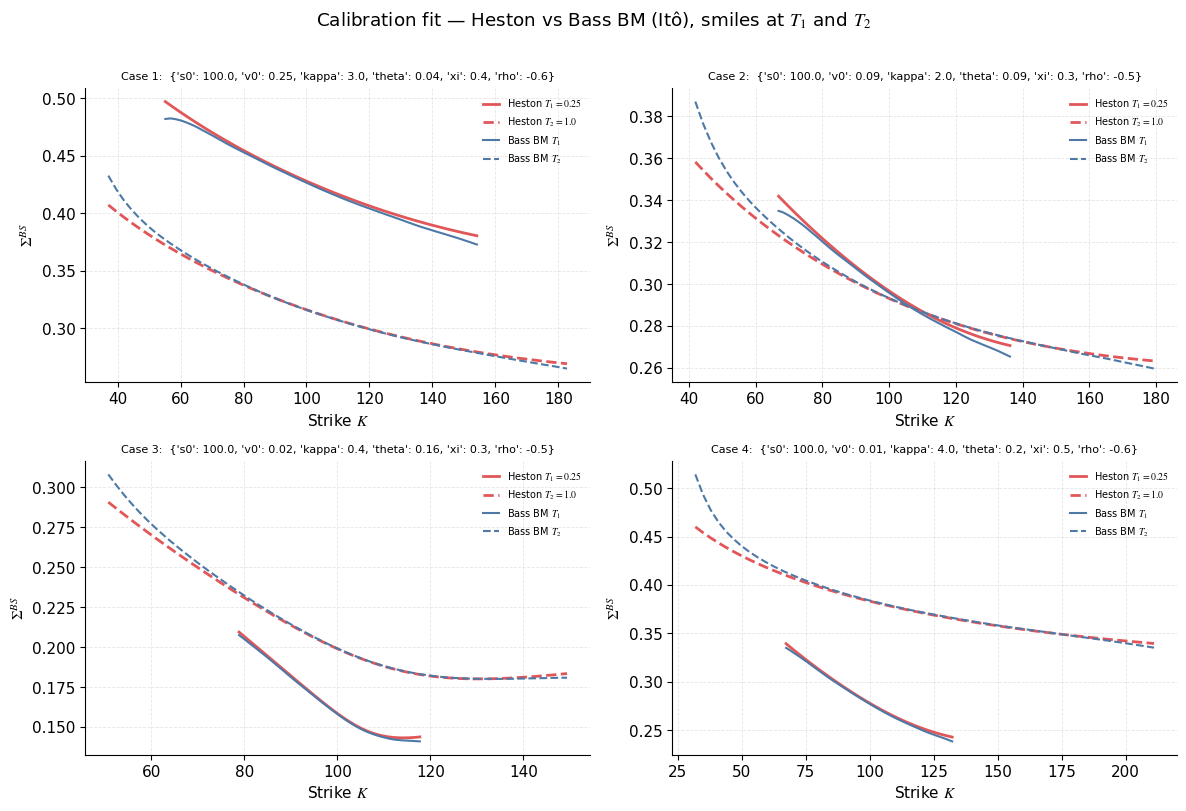

In [48]:
# ── Smile fit: Heston vs Bass BM at T₁ and T₂  (4 subplots × 2 smiles each) ──
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (mkt, sim) in enumerate(zip(markets, simulations)):
    ax = axes[i]
    h  = mkt.model
    qf1, qf2 = mkt.qf[1], mkt.qf[2]

    K1 = np.linspace(qf1(0.01), qf1(0.99), 60)
    K2 = np.linspace(qf2(0.01), qf2(0.99), 60)

    ax.plot(K1, h.implied_vol(T[1], K1),                    color=C['market'], lw=2,   ls='-',  label=f'Heston $T_1={T[1]}$')
    ax.plot(K2, h.implied_vol(T[2], K2),                    color=C['market'], lw=2,   ls='--', label=f'Heston $T_2={T[2]}$')
    ax.plot(K1, mc_iv(s0, T[1], K1, sim['X1'][:, -1]), color=C['model'],  lw=1.5, ls='-',  label=f'Bass BM $T_1$')
    ax.plot(K2, mc_iv(s0, T[2], K2, sim['X2'][:, -1]), color=C['model'],  lw=1.5, ls='--', label=f'Bass BM $T_2$')

    ax.set_title(f"Case {i+1}:  {heston_params[i]}", fontsize=8)
    ax.set_xlabel("Strike $K$");  ax.set_ylabel("$\\Sigma^{BS}$")
    ax.legend(fontsize=7)

plt.suptitle("Calibration fit — Heston vs Bass BM (Itô), smiles at $T_1$ and $T_2$", y=1.01)
plt.tight_layout()
plt.show()

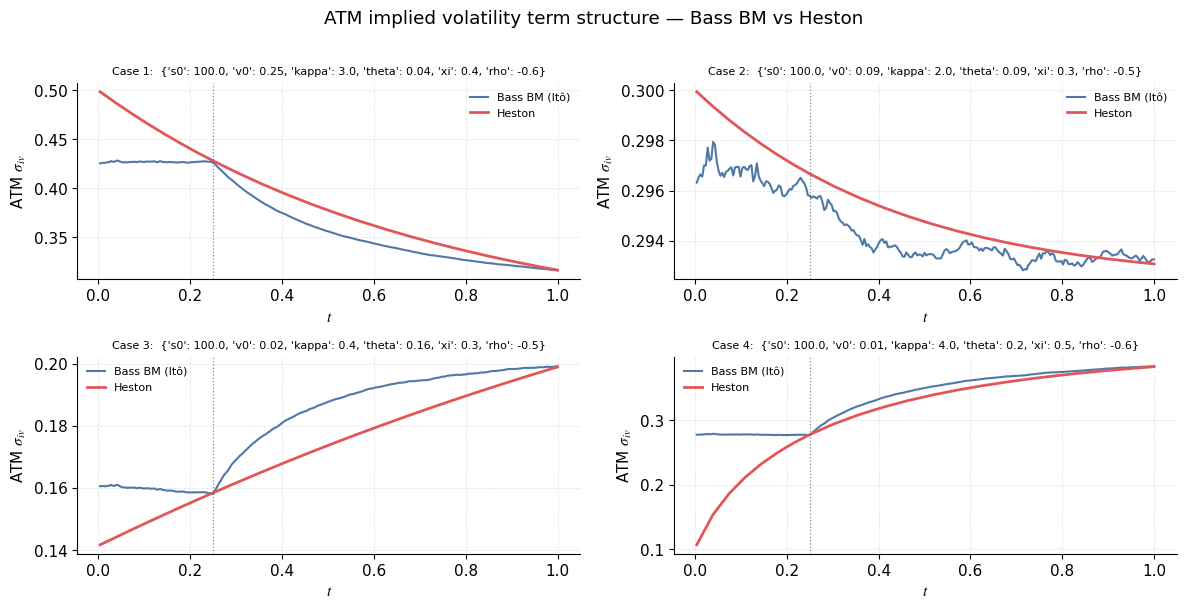

In [51]:
# ── ATM implied vol term structure  (4 subplots) ──────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes = axes.flatten()

for i, (sim, ana) in enumerate(zip(simulations, analyses)):
    ax = axes[i]
    ax.plot(sim['t_full'][1:], ana['atm_iv_bass'], color=C['model'],  lw=1.5, label='Bass BM (Itô)')
    ax.plot(ana['t_heston'],   ana['heston_atm'],  color=C['market'], lw=2.0, label='Heston')
    vline(ax, T[1])
    ax.set_title(f"Case {i+1}:  {heston_params[i]}", fontsize=8)
    ax.set_xlabel("$t$");  ax.set_ylabel("ATM $\\sigma_{iv}$")
    ax.legend(fontsize=8)

plt.suptitle("ATM implied volatility term structure — Bass BM vs Heston", y=1.01)
plt.tight_layout()
plt.show()

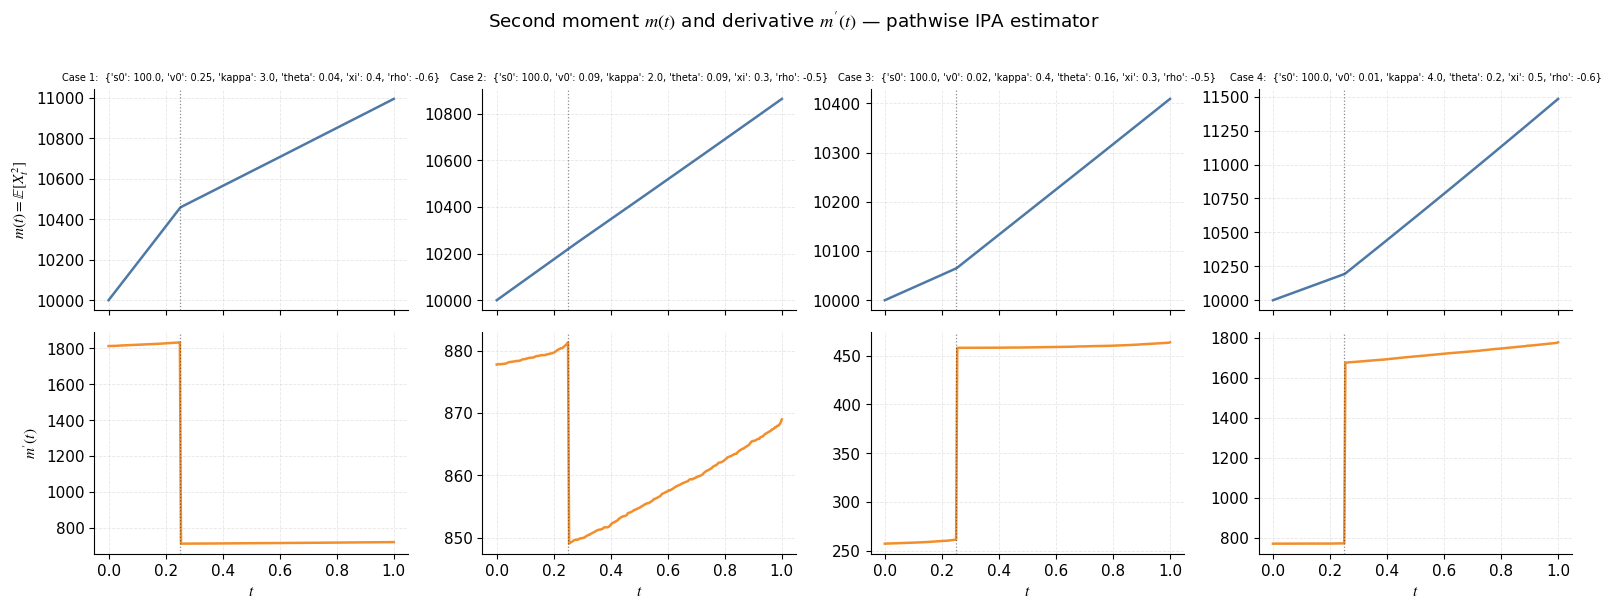

In [44]:
# ── Second moment m(t) and m'(t)  (2 rows × 4 cols) ──────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharex='col')

for i, ana in enumerate(analyses):
    axes[0, i].plot(ana['t_m'], ana['m_t'],  color=C['model'])
    vline(axes[0, i], T[1])
    axes[0, i].set_title(f"Case {i+1}:  {heston_params[i]}", fontsize=7)
    if i == 0:
        axes[0, i].set_ylabel("$m(t) = \\mathbb{E}[X_t^2]$")

    axes[1, i].plot(ana['t_m'], ana['mp_t'], color=C['aux'])
    vline(axes[1, i], T[1])
    axes[1, i].set_xlabel("$t$")
    if i == 0:
        axes[1, i].set_ylabel("$m'(t)$")

plt.suptitle("Second moment $m(t)$ and derivative $m'(t)$ — pathwise IPA estimator", y=1.01)
plt.tight_layout()
plt.show()